# Part 2: RFM Segmentation & Retention Strategy

## Business Objective

The company wants to identify customer groups that require retention attention before deploying a machine learning churn model.

This analysis uses:

- RFM (Recency, Frequency, Monetary) metrics
- Support behaviour
- Return behaviour
- Discount usage
- Website engagement

The final output will:

1. Create customer segments
2. Explain customer behaviour
3. Recommend retention actions
4. Prioritize campaign budget
5. Identify customers requiring manual review

In [ ]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


## Load Dataset

We load all datasets required for segmentation.

Only data available on or before the snapshot date
(2025-09-30) will be used.

This prevents data leakage and ensures that segmentation
is based only on information known at the time.

In [ ]:


customers = pd.read_csv("../data/customers.csv")
orders = pd.read_csv("../data/orders.csv")
tickets = pd.read_csv("../data/support_tickets.csv")
web = pd.read_csv("../data/web_events_snapshot.csv")

print("Customers Shape :", customers.shape)
print("Orders Shape    :", orders.shape)
print("Tickets Shape   :", tickets.shape)
print("Web Shape       :", web.shape)

Customers Shape : (2400, 9)
Orders Shape    : (10009, 10)
Tickets Shape   : (1921, 8)
Web Shape       : (2400, 10)


In [15]:


print("CUSTOMERS")
display(customers.head())

print("ORDERS")
display(orders.head())

print("SUPPORT TICKETS")
display(tickets.head())

print("WEB EVENTS")
display(web.head())

CUSTOMERS


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes


ORDERS


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


SUPPORT TICKETS


,ticket_id,customer_id,ticket_date,issue_type,support_channel,resolution_hours,sentiment_score,reopened
0,TKT000001,CUST00001,2024-10-28,damaged_item,chat,3.9,-0.16,0
1,TKT000002,CUST00001,2025-02-03,payment_issue,chat,4.8,0.44,0
2,TKT000003,CUST00002,2025-08-30,late_delivery,chat,1.0,0.00,0
3,TKT000004,CUST00005,2025-05-02,late_delivery,call,37.7,-1.00,0
4,TKT000005,CUST00006,2025-08-13,general_query,call,23.1,-0.68,1


WEB EVENTS


,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26
3,CUST00004,2025-09-30,1,6,0,0,0,0,0,14
4,CUST00005,2025-09-30,18,95,4,1,1,3,1,9


## Data Preparation

The segmentation must only use information available
before the snapshot date.

Therefore:

- Convert date columns
- Remove post-snapshot transactions
- Create a clean transaction dataset

In [17]:

# Date Conversion

orders["order_date"] = pd.to_datetime(
    orders["order_date"]
)

tickets["ticket_date"] = pd.to_datetime(
    tickets["ticket_date"]
)

customers["signup_date"] = pd.to_datetime(
    customers["signup_date"]
)

snapshot_date = pd.Timestamp("2025-09-30")

print("Date Conversion Complete")
print("Snapshot Date:", snapshot_date)

Date Conversion Complete
Snapshot Date: 2025-09-30 00:00:00


In [19]:

# Remove Future Orders


orders_pre = orders[
    orders["order_date"] <= snapshot_date
].copy()

print("Orders Before Filtering :", len(orders))
print("Orders After Filtering  :", len(orders_pre))

print("\nLatest Available Order:")
print(orders_pre["order_date"].max())

Orders Before Filtering : 10009
Orders After Filtering  : 8137

Latest Available Order:
2025-09-30 00:00:00


## RFM Feature Engineering

RFM stands for:

### Recency
Days since last purchase.

### Frequency
Total number of purchases.

### Monetary
Total customer spend.

These metrics are widely used for customer segmentation
and retention planning.

In [20]:


recency = (
    orders_pre
    .groupby("customer_id")["order_date"]
    .max()
    .reset_index()
)

recency["recency"] = (
    snapshot_date -
    recency["order_date"]
).dt.days

recency = recency[
    ["customer_id","recency"]
]

print("Recency Created")
display(recency.head())

Recency Created


,customer_id,recency
0,CUST00001,107
1,CUST00002,40
2,CUST00003,171
3,CUST00004,131
4,CUST00005,38


In [21]:
frequency = (
    orders_pre
    .groupby("customer_id")
    .size()
    .reset_index(name="frequency")
)

print("Frequency Created")
display(frequency.head())

Frequency Created


,customer_id,frequency
0,CUST00001,6
1,CUST00002,1
2,CUST00003,1
3,CUST00004,1
4,CUST00005,4


In [ ]:

# Create Monetary


monetary = (
    orders_pre
    .groupby("customer_id")["gross_amount"]
    .sum()
    .reset_index()
)

monetary.columns = [
    "customer_id",
    "monetary"
]

print("Monetary Created")
display(monetary.head())

Monetary Created


,customer_id,monetary
0,CUST00001,2955.57
1,CUST00002,581.00
2,CUST00003,649.98
3,CUST00004,1604.04
4,CUST00005,2550.91


In [23]:
rfm = (
    recency
    .merge(frequency,on="customer_id")
    .merge(monetary,on="customer_id")
)

print("RFM Table Shape:", rfm.shape)

display(rfm.head())

RFM Table Shape: (2400, 4)


,customer_id,recency,frequency,monetary
0,CUST00001,107,6,2955.57
1,CUST00002,40,1,581.00
2,CUST00003,171,1,649.98
3,CUST00004,131,1,1604.04
4,CUST00005,38,4,2550.91


In [24]:
display(
    rfm[
        ["recency","frequency","monetary"]
    ].describe()
)

,recency,frequency,monetary
count,2400.000000,2400.000000,2400.000000
mean,87.375833,3.390417,2549.655729
std,80.137473,2.383350,2129.104340
min,0.000000,1.000000,149.000000
25%,25.000000,1.000000,955.380000
50%,66.000000,3.000000,2012.020000
75%,129.000000,5.000000,3566.080000
max,562.000000,16.000000,27215.920000


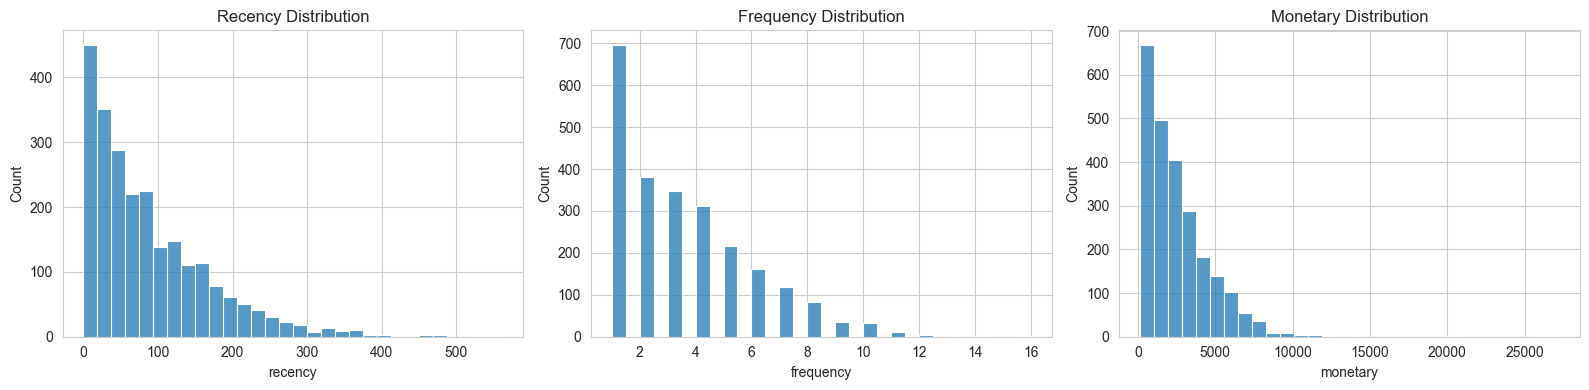

Saved: charts/rfm_distribution.png


In [ ]:

# RFM Distribution


fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(
    rfm["recency"],
    bins=30,
    ax=axes[0]
)
axes[0].set_title("Recency Distribution")

sns.histplot(
    rfm["frequency"],
    bins=30,
    ax=axes[1]
)
axes[1].set_title("Frequency Distribution")

sns.histplot(
    rfm["monetary"],
    bins=30,
    ax=axes[2]
)
axes[2].set_title("Monetary Distribution")

plt.tight_layout()

# Save Chart
plt.savefig(
    "charts/rfm_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

print("Saved: charts/rfm_distribution.png")

## Task 2: Additional Behavioural and Support Signals

RFM metrics alone do not fully describe customer behaviour.

To improve customer understanding, the following additional signals are created:

### Return Rate
Measures the percentage of orders returned.

### Discount Usage
Measures how dependent a customer is on discounts.

### Category Diversity
Measures how many different product categories a customer purchases from.

### Support Activity
Measures customer service interactions and dissatisfaction.

### Website & Campaign Engagement
Measures customer interaction with the website and marketing campaigns.

These signals will later be combined with RFM metrics to create business-driven customer segments.

In [ ]:
#
# TASK 2
# Create Additional Behavioural Signals


# Return Rate


return_rate = (
    orders_pre
    .groupby("customer_id")["returned"]
    .mean()
    .reset_index()
)

return_rate.columns = [
    "customer_id",
    "return_rate"
]

# Average Discount Usage


discount_usage = (
    orders_pre
    .groupby("customer_id")["discount_pct"]
    .mean()
    .reset_index()
)

discount_usage.columns = [
    "customer_id",
    "avg_discount_pct"
]


# Category Diversity


category_diversity = (
    orders_pre
    .groupby("customer_id")["category"]
    .nunique()
    .reset_index()
)

category_diversity.columns = [
    "customer_id",
    "category_diversity"
]

# Support Ticket Count


ticket_count = (
    tickets
    .groupby("customer_id")
    .size()
    .reset_index(name="ticket_count")
)


# Negative Ticket Rate


negative_sentiment = (
    tickets
    .assign(
        negative=np.where(
            tickets["sentiment_score"] < 0,
            1,
            0
        )
    )
    .groupby("customer_id")["negative"]
    .mean()
    .reset_index()
)

negative_sentiment.columns = [
    "customer_id",
    "negative_ticket_rate"
]


# Web & Campaign Engagement


web_features = web[
    [
        "customer_id",
        "sessions_30d",
        "campaign_clicks_30d",
        "email_opens_30d",
        "last_visit_days_ago"
    ]
]


# Merge Everything


rfm_final = (
    rfm
    .merge(return_rate, on="customer_id", how="left")
    .merge(discount_usage, on="customer_id", how="left")
    .merge(category_diversity, on="customer_id", how="left")
    .merge(ticket_count, on="customer_id", how="left")
    .merge(negative_sentiment, on="customer_id", how="left")
    .merge(web_features, on="customer_id", how="left")
)

rfm_final.fillna(0, inplace=True)

print("Final Dataset Shape:", rfm_final.shape)

display(rfm_final.head())

display(
    rfm_final[
        [
            "return_rate",
            "avg_discount_pct",
            "category_diversity",
            "ticket_count",
            "negative_ticket_rate",
            "sessions_30d"
        ]
    ].describe()
)

Final Dataset Shape: (2400, 13)


,customer_id,recency,frequency,monetary,return_rate,avg_discount_pct,category_diversity,ticket_count,negative_ticket_rate,sessions_30d,campaign_clicks_30d,email_opens_30d,last_visit_days_ago
0,CUST00001,107,6,2955.57,0.166667,0.363333,3,2.0,0.5,1,0,2,20
1,CUST00002,40,1,581.00,0.000000,0.230000,1,1.0,0.0,8,0,0,0
2,CUST00003,171,1,649.98,0.000000,0.470000,1,0.0,0.0,1,0,0,26
3,CUST00004,131,1,1604.04,0.000000,0.160000,1,0.0,0.0,1,0,0,14
4,CUST00005,38,4,2550.91,0.000000,0.442500,2,1.0,1.0,18,1,3,9


,return_rate,avg_discount_pct,category_diversity,ticket_count,negative_ticket_rate,sessions_30d
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,0.067783,0.280694,2.351250,0.800417,0.412451,5.460000
std,0.182078,0.096076,1.260371,0.976890,0.476689,4.400167
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,0.216667,1.000000,0.000000,0.000000,2.000000
50%,0.000000,0.280000,2.000000,1.000000,0.000000,5.000000
75%,0.000000,0.340000,3.000000,1.000000,1.000000,8.000000
max,1.000000,0.640000,6.000000,6.000000,1.000000,25.000000


## Task 3: Customer Segmentation

Customer segmentation was performed using RFM metrics combined with behavioural and support signals.

### RFM Metrics
- Recency
- Frequency
- Monetary Value

### Additional Signals
- Support Complaints (ticket_count)
- Return Rate (return_rate)
- Website Activity (sessions_30d)
- Campaign Engagement (campaign_clicks_30d)
- Discount Usage (avg_discount_pct)
- Category Diversity (category_diversity)

The goal is to create actionable customer groups that can be targeted with different retention strategies.

In [31]:
high_recency = rfm_final["recency"].quantile(0.80)

low_recency = rfm_final["recency"].quantile(0.20)

high_frequency = rfm_final["frequency"].quantile(0.80)

high_monetary = rfm_final["monetary"].quantile(0.80)

high_discount = rfm_final["avg_discount_pct"].quantile(0.80)

high_sessions = rfm_final["sessions_30d"].quantile(0.80)

high_campaign = rfm_final["campaign_clicks_30d"].quantile(0.80)

def assign_segment(row):

    if (
        row["recency"] <= low_recency
        and row["frequency"] >= high_frequency
        and row["monetary"] >= high_monetary
        and row["sessions_30d"] >= high_sessions
    ):
        return "Champions"

    elif (
        row["frequency"] >= high_frequency
        and row["campaign_clicks_30d"] >= high_campaign
    ):
        return "Loyal Customers"

    elif (
        row["monetary"] >= high_monetary
        and (
            row["ticket_count"] >= 2
            or row["return_rate"] >= 0.20
            or row["negative_ticket_rate"] >= 0.50
        )
    ):
        return "High Value But Unhappy"

    elif (
        row["monetary"] >= high_monetary
        and row["recency"] >= high_recency
    ):
        return "At-Risk High Value"

    elif (
        row["avg_discount_pct"] >= high_discount
    ):
        return "Discount Sensitive"

    else:
        return "Dormant Customers"


rfm_final["segment_name"] = rfm_final.apply(
    assign_segment,
    axis=1
)

segment_counts = (
    rfm_final["segment_name"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = [
    "Segment",
    "Customer_Count"
]

print("Customer Segment Distribution")
display(segment_counts)

Customer Segment Distribution


,Segment,Customer_Count
0,Dormant Customers,1479
1,Discount Sensitive,421
2,Loyal Customers,258
3,High Value But Unhappy,184
4,Champions,47
5,At-Risk High Value,11


In [32]:
segment_summary = (
    rfm_final
    .groupby("segment_name")
    [
        [
            "recency",
            "frequency",
            "monetary",
            "return_rate",
            "avg_discount_pct",
            "ticket_count",
            "sessions_30d",
            "campaign_clicks_30d",
            "category_diversity"
        ]
    ]
    .mean()
    .round(2)
)

display(segment_summary)

,recency,frequency,monetary,return_rate,avg_discount_pct,ticket_count,sessions_30d,campaign_clicks_30d,category_diversity
segment_name,,,,,,,,,
At-Risk High Value,191.36,5.27,5164.52,0.00,0.22,0.18,3.09,0.00,3.18
Champions,6.87,7.49,6075.14,0.06,0.27,1.77,11.85,1.30,4.17
Discount Sensitive,88.47,2.22,1351.41,0.07,0.42,0.55,5.33,0.59,1.76
Dormant Customers,90.96,2.60,1949.55,0.07,0.24,0.56,5.20,0.55,2.03
High Value But Unhappy,77.32,6.72,5790.43,0.09,0.27,2.04,5.15,0.05,3.77
Loyal Customers,82.46,6.60,4880.12,0.07,0.28,1.58,6.31,1.65,3.78


## Task 4: Retention Actions by Segment

The purpose of segmentation is not just to label customers, but to decide the next business action for each group.

| Segment | Customer Behaviour | Retention Action | Business Reason |
|---|---|---|---|
| Champions | Recent, frequent, high-spending, highly engaged customers | Give VIP treatment, early access to new launches, loyalty rewards, and referral offers | Protect the most valuable customers and increase advocacy |
| Loyal Customers | Repeated purchasers with stable spending and decent engagement | Offer bundles, cross-sell recommendations, and loyalty-point boosters | Increase basket size and lifetime value without heavy discounts |
| At-Risk High Value | High historical spend but low recent activity | Send personalized win-back messages, premium offers, and direct CRM outreach | These customers can generate major revenue if reactivated quickly |
| Discount Sensitive | Customers who buy mainly when discounts are available | Use targeted coupon campaigns, festival offers, and limited-time deals | Retain them using controlled discounting instead of broad promotions |
| High Value But Unhappy | High-spending customers with returns, complaints, or negative support signals | Trigger service recovery, apology outreach, issue resolution, and selective compensation | Fix dissatisfaction before the customer is lost |
| Dormant Customers | Low engagement, weak purchase activity, long inactivity | Run low-cost reactivation campaigns with simple reminders or low-value win-back offers | Some can be recovered, but cost should stay low because conversion is uncertain |

### Campaign Budget Prioritization

If the budget is limited, the priority order should be:

1. At-Risk High Value  
2. High Value But Unhappy  
3. Champions  
4. Loyal Customers  
5. Discount Sensitive  
6. Dormant Customers  

### Budget Logic

The first two groups should get the highest attention because they combine high revenue potential with clear risk. Champions should be protected next because they already contribute strongly to revenue and loyalty. Loyal and discount-sensitive customers can be handled with cheaper scalable offers. Dormant customers should be targeted last because recovery probability is usually lower.

## Task 5: Manual Review Cases

Not every customer fits perfectly into a single segment.

Some customers show conflicting signals such as:

- High spending but multiple complaints
- Strong engagement but declining purchases
- High discount dependence despite strong purchase history
- High website activity but low transaction activity

These customers require manual review before a retention action is finalized.

In [33]:
manual_review = rfm_final[
    (
        (
            rfm_final["monetary"]
            >=
            rfm_final["monetary"].quantile(0.80)
        )
        &
        (
            rfm_final["ticket_count"] >= 2
        )
    )
    |
    (
        (
            rfm_final["sessions_30d"]
            >=
            rfm_final["sessions_30d"].quantile(0.80)
        )
        &
        (
            rfm_final["frequency"]
            <=
            rfm_final["frequency"].quantile(0.30)
        )
    )
    |
    (
        (
            rfm_final["avg_discount_pct"]
            >=
            rfm_final["avg_discount_pct"].quantile(0.80)
        )
        &
        (
            rfm_final["monetary"]
            >=
            rfm_final["monetary"].quantile(0.60)
        )
    )
]

manual_review = manual_review[
    [
        "customer_id",
        "segment_name",
        "recency",
        "frequency",
        "monetary",
        "return_rate",
        "avg_discount_pct",
        "ticket_count",
        "negative_ticket_rate",
        "sessions_30d",
        "campaign_clicks_30d"
    ]
]

manual_review = manual_review.head(10)

display(manual_review)

,customer_id,segment_name,recency,frequency,monetary,return_rate,avg_discount_pct,ticket_count,negative_ticket_rate,sessions_30d,campaign_clicks_30d
0,CUST00001,Discount Sensitive,107,6,2955.57,0.166667,0.363333,2.0,0.500000,1,0
6,CUST00007,Dormant Customers,3,1,719.33,0.000000,0.180000,0.0,0.000000,11,3
8,CUST00009,Discount Sensitive,31,1,376.85,0.000000,0.490000,0.0,0.000000,11,0
9,CUST00010,Discount Sensitive,9,1,636.80,0.000000,0.450000,0.0,0.000000,13,0
10,CUST00011,Dormant Customers,1,2,925.07,0.000000,0.155000,0.0,0.000000,10,0
13,CUST00014,High Value But Unhappy,51,11,8130.16,0.000000,0.261818,2.0,0.500000,11,0
21,CUST00022,Dormant Customers,29,1,454.06,0.000000,0.310000,0.0,0.000000,10,1
23,CUST00024,Dormant Customers,4,1,481.35,0.000000,0.340000,0.0,0.000000,13,0
24,CUST00025,Loyal Customers,165,7,4868.86,0.000000,0.311429,3.0,0.666667,11,1
26,CUST00027,Dormant Customers,70,1,2128.34,1.000000,0.300000,1.0,1.000000,11,2


In [35]:
manual_review.to_csv(
    "manual_review_customers.csv",
    index=False
)

In [43]:
segments_export = rfm_final[
    [
        "customer_id",
        "segment_name",
        "recency",
        "frequency",
        "monetary",
        "return_rate",
        "avg_discount_pct",
        "ticket_count",
        "negative_ticket_rate",
        "sessions_30d",
        "campaign_clicks_30d",
        "category_diversity"
    ]
]

print(segments_export.shape)

display(segments_export.head())

(2400, 12)


,customer_id,segment_name,recency,frequency,monetary,return_rate,avg_discount_pct,ticket_count,negative_ticket_rate,sessions_30d,campaign_clicks_30d,category_diversity
0,CUST00001,Discount Sensitive,107,6,2955.57,0.166667,0.363333,2.0,0.5,1,0,3
1,CUST00002,Dormant Customers,40,1,581.00,0.000000,0.230000,1.0,0.0,8,0,1
2,CUST00003,Discount Sensitive,171,1,649.98,0.000000,0.470000,0.0,0.0,1,0,1
3,CUST00004,Dormant Customers,131,1,1604.04,0.000000,0.160000,0.0,0.0,1,0,1
4,CUST00005,Discount Sensitive,38,4,2550.91,0.000000,0.442500,1.0,1.0,18,1,2


In [44]:
segments_export.to_csv(
    "segments.csv",
    index=False
)

print("segments.csv saved successfully")

segments.csv saved successfully
